<a href="https://colab.research.google.com/github/eniompw/microgpt-tinystories/blob/main/microgpt-colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MicroGPT — PyTorch (Colab T4 GPU)

The most atomic way to train and run inference for a GPT in pure PyTorch.
Based on [@karpathy](https://github.com/karpathy)'s microgpt.

> **Runtime:** Go to **Runtime → Change runtime type → T4 GPU** before running.

## 1. GPU Setup and Library Imports

In [8]:
import os
import random
import json
import torch
import torch.nn.functional as F

# Reproducibility
random.seed(42)
torch.manual_seed(42)

# Device setup — will use T4 GPU on Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Dataset Download and Preparation

In [9]:
import urllib.request

if not os.path.exists('input.txt'):
    print("Downloading TinyStories dataset from HuggingFace...")
    stories = []
    base_url = 'https://datasets-server.huggingface.co/rows?dataset=karpathy/tinystories-gpt4-clean&config=default&split=train'
    for offset in range(20000, 25000, 100):  # 5000 stories
        url = f'{base_url}&offset={offset}&limit=100'
        with urllib.request.urlopen(url) as response:
            data = json.loads(response.read())
        for item in data['rows']:
            stories.append(item['row']['text'])
        print(f"  fetched {len(stories)} stories...", end='\r')
    print()
    with open('input.txt', 'w') as f:
        for story in stories:
            f.write(json.dumps(story) + '\n')
    print("Saved to input.txt")
else:
    print("input.txt already exists, skipping download.")

docs = [json.loads(line) for line in open('input.txt') if line.strip()]
random.shuffle(docs)
print(f"num docs: {len(docs)}")
print(f"sample doc: {docs[0][:120]}...")


  fetched 5000 stories...
Saved to input.txt
num docs: 5000
sample doc: Ben and Lily were playing in the farm with their new friend, Mira the mule. Mira was very strong and gentle, and she lik...


## 3. Tokenizer Setup

In [10]:
# Character-level vocabulary — all 74 chars present in the dataset
uchars = sorted('\n !"$\',-.' + '0123456789:;?' + 'ABCDEFGHIJKLMNOPQRSTUVWXYZ' + 'abcdefghijklmnopqrstuvwxyz')
BOS = len(uchars)          # special Beginning-of-Sequence token id
vocab_size = len(uchars) + 1
print(f"vocab size: {vocab_size}")
print(f"BOS token id: {BOS}")

# Encode / decode helpers
encode = lambda s: [uchars.index(ch) for ch in s]
decode = lambda ids: ''.join(uchars[i] for i in ids)

# Sanity check
sample_text = "Once upon a time"
encoded = encode(sample_text)
decoded = decode(encoded)
print(f"encode('{sample_text}') → {encoded}")
print(f"decode(...)           → '{decoded}'")

vocab size: 75
BOS token id: 74
encode('Once upon a time') → [36, 61, 50, 52, 1, 68, 63, 62, 61, 1, 48, 1, 67, 56, 60, 52]
decode(...)           → 'Once upon a time'


## 4. Model Hyperparameters and Parameter Initialization

In [11]:
import math

# ── Hyperparameters ───────────────────────────────────────────────────────────
n_layer    = 5       # transformer depth
n_embd     = 128     # embedding dim
block_size = 256     # context window
n_head     = 8       # attention heads
head_dim   = n_embd // n_head
batch_size = 32

# ── Weight init ──────────────────────────────────────────────────────────────
matrix = lambda nout, nin: torch.randn(nout, nin, device=device) * 0.02

state_dict = {
    'wte': matrix(vocab_size, n_embd),   # token embeddings (weight-tied to lm_head)
}
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)

params = list(state_dict.values())
for p in params:
    p.requires_grad_(True)

total_params = sum(p.numel() for p in params)
print(f"num params: {total_params:,}")
print(f"tokens per iter: {batch_size * block_size:,}")


num params: 992,640
tokens per iter: 8,192


## 5. Model Architecture Definition

Llama-style transformer: RMSNorm, RoPE, flash attention, weight tying.


In [12]:
def rmsnorm(x):
    """RMSNorm along last dim — works for any shape."""
    return x * (x.pow(2).mean(-1, keepdim=True) + 1e-5).rsqrt()

# ── RoPE (Rotary Position Embeddings) ────────────────────────────────────────
freqs = 1.0 / (10000.0 ** (torch.arange(0, head_dim, 2, device=device).float() / head_dim))
freqs = torch.outer(torch.arange(block_size, device=device).float(), freqs)
rope_cos, rope_sin = freqs.cos(), freqs.sin()   # (block_size, head_dim//2)

def apply_rope(x, cos, sin):
    """x: (B,T,H,D) or (H,D). cos/sin: (T,D//2) or (D//2,)"""
    d = x.dtype
    x = x.float().unflatten(-1, (-1, 2))
    x_r, x_i = x[..., 0], x[..., 1]
    if x.dim() == 5:  # batched
        cos = cos.view(1, -1, 1, cos.shape[-1])
        sin = sin.view(1, -1, 1, sin.shape[-1])
    return torch.stack([x_r*cos - x_i*sin, x_r*sin + x_i*cos], -1).flatten(-2).to(d)

# ── Batched forward (for training) ───────────────────────────────────────────
def gpt_train(tokens):
    """tokens: (B, T) long -> logits: (B, T, vocab_size)"""
    bsz, seqlen = tokens.shape
    x = rmsnorm(F.embedding(tokens, state_dict['wte']))
    cos, sin = rope_cos[:seqlen], rope_sin[:seqlen]
    for li in range(n_layer):
        r = x
        x = rmsnorm(x)
        q = F.linear(x, state_dict[f'layer{li}.attn_wq']).view(bsz, seqlen, n_head, head_dim)
        k = F.linear(x, state_dict[f'layer{li}.attn_wk']).view(bsz, seqlen, n_head, head_dim)
        v = F.linear(x, state_dict[f'layer{li}.attn_wv']).view(bsz, seqlen, n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        x = F.scaled_dot_product_attention(
            q.transpose(1,2), k.transpose(1,2), v.transpose(1,2), is_causal=True
        ).transpose(1,2).contiguous().view(bsz, seqlen, -1)
        x = F.linear(x, state_dict[f'layer{li}.attn_wo']) + r
        r = x
        x = rmsnorm(x)
        x = F.relu(F.linear(x, state_dict[f'layer{li}.mlp_fc1']))
        x = F.linear(x, state_dict[f'layer{li}.mlp_fc2']) + r
    return F.linear(rmsnorm(x), state_dict['wte'])   # weight-tied lm_head

# ── Single-token forward (for inference with KV cache) ───────────────────────
def gpt(token_id, pos_id, keys, values):
    x = rmsnorm(state_dict['wte'][token_id])
    cos, sin = rope_cos[pos_id], rope_sin[pos_id]
    for li in range(n_layer):
        r = x
        x = rmsnorm(x)
        q = F.linear(x, state_dict[f'layer{li}.attn_wq']).view(n_head, head_dim)
        k = F.linear(x, state_dict[f'layer{li}.attn_wk']).view(n_head, head_dim)
        v = F.linear(x, state_dict[f'layer{li}.attn_wv']).view(n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        keys[li].append(k); values[li].append(v)
        x_attn = []
        for h in range(n_head):
            k_h = torch.stack([ki[h] for ki in keys[li]])
            v_h = torch.stack([vi[h] for vi in values[li]])
            x_attn.append(F.softmax(k_h @ q[h] / head_dim**0.5, dim=0) @ v_h)
        x = F.linear(torch.cat(x_attn), state_dict[f'layer{li}.attn_wo']) + r
        r = x
        x = rmsnorm(x)
        x = F.relu(F.linear(x, state_dict[f'layer{li}.mlp_fc1']))
        x = F.linear(x, state_dict[f'layer{li}.mlp_fc2']) + r
    return F.linear(rmsnorm(x), state_dict['wte'])

print("Model functions defined.")


Model functions defined.


## 6. Training Loop

Total tokens: 4,051,708
step    0/3000 | loss 4.4627 | lr 5.00e-04 | 0.0s
step  100/3000 | loss 2.4109 | lr 4.83e-04 | 2.6s
step  200/3000 | loss 2.0018 | lr 4.67e-04 | 6.1s
step  300/3000 | loss 1.6843 | lr 4.50e-04 | 8.6s
step  400/3000 | loss 1.5325 | lr 4.33e-04 | 11.2s
step  500/3000 | loss 1.3961 | lr 4.17e-04 | 13.8s
step  600/3000 | loss 1.3162 | lr 4.00e-04 | 16.4s
step  700/3000 | loss 1.2868 | lr 3.83e-04 | 19.1s
step  800/3000 | loss 1.2588 | lr 3.67e-04 | 21.6s
step  900/3000 | loss 1.2072 | lr 3.50e-04 | 24.2s
step 1000/3000 | loss 1.1357 | lr 3.33e-04 | 26.8s
step 1100/3000 | loss 1.1485 | lr 3.17e-04 | 29.4s
step 1200/3000 | loss 1.1331 | lr 3.00e-04 | 32.1s
step 1300/3000 | loss 1.1383 | lr 2.83e-04 | 34.7s
step 1400/3000 | loss 1.0577 | lr 2.67e-04 | 37.3s
step 1500/3000 | loss 1.0148 | lr 2.50e-04 | 39.9s
step 1600/3000 | loss 1.0420 | lr 2.33e-04 | 42.7s
step 1700/3000 | loss 1.0865 | lr 2.17e-04 | 45.2s
step 1800/3000 | loss 1.0436 | lr 2.00e-04 | 47.8s
step 1900/3

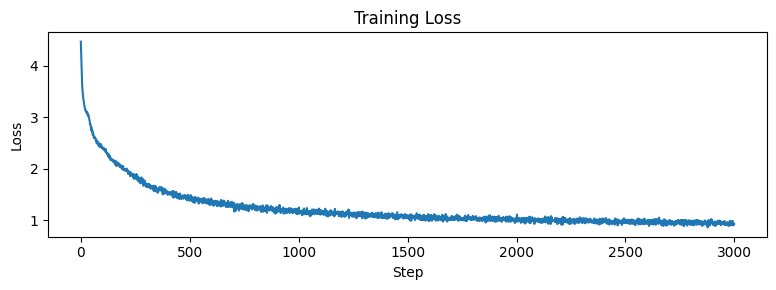

In [13]:
import time
import matplotlib.pyplot as plt

# ── Prepare token stream ─────────────────────────────────────────────────────
all_tokens = []
for doc in docs:
    all_tokens.extend([BOS] + encode(doc))
all_tokens.append(BOS)
all_tokens = torch.tensor(all_tokens, dtype=torch.long, device=device)
print(f"Total tokens: {len(all_tokens):,}")

# ── Optimizer: AdamW ─────────────────────────────────────────────────────────
num_steps     = 3000
learning_rate = 5e-4

optimizer = torch.optim.AdamW(params, lr=learning_rate, betas=(0.9, 0.95), eps=1e-10)

# Mixed precision (float16 on T4)
scaler = torch.amp.GradScaler('cuda')

# ── Training loop ────────────────────────────────────────────────────────────
loss_history = []
t0 = time.time()

for step in range(num_steps + 1):
    # Linear learning rate decay
    lr_t = learning_rate * (1 - step / num_steps)
    for g in optimizer.param_groups:
        g['lr'] = lr_t

    if step % 100 == 0:
        with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
            ix = torch.randint(0, len(all_tokens) - block_size - 1, (batch_size,))
            xb = torch.stack([all_tokens[i:i+block_size] for i in ix])
            yb = torch.stack([all_tokens[i+1:i+block_size+1] for i in ix])
            el = F.cross_entropy(gpt_train(xb).view(-1, vocab_size), yb.view(-1)).item()
        print(f"step {step:4d}/{num_steps} | loss {el:.4f} | lr {lr_t:.2e} | {time.time()-t0:.1f}s")

    if step >= num_steps:
        break

    optimizer.zero_grad()
    ix = torch.randint(0, len(all_tokens) - block_size - 1, (batch_size,))
    xb = torch.stack([all_tokens[i:i+block_size] for i in ix])
    yb = torch.stack([all_tokens[i+1:i+block_size+1] for i in ix])
    with torch.amp.autocast('cuda', dtype=torch.float16):
        loss = F.cross_entropy(gpt_train(xb).view(-1, vocab_size), yb.view(-1))
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    loss_history.append(loss.item())

print(f"\nDone in {time.time()-t0:.1f}s")
plt.figure(figsize=(8, 3))
plt.plot(loss_history)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Training Loss')
plt.tight_layout(); plt.show()


## 7. Inference and Text Generation

In [14]:
temperature = 0.8   # (0, 1] — lower = more focused, higher = more random
num_samples = 5
max_new_tokens = 200  # generate up to this many tokens per sample

print("--- inference (hallucinated stories) ---\n")
for sample_idx in range(num_samples):
    keys   = [[] for _ in range(n_layer)]
    values = [[] for _ in range(n_layer)]
    token_id = BOS
    sample = []
    with torch.no_grad():
        for pos_id in range(max_new_tokens):
            pos = min(pos_id, block_size - 1)
            logits = gpt(token_id, pos, keys, values)
            probs  = F.softmax(logits[:vocab_size] / temperature, dim=-1)
            token_id = torch.multinomial(probs, 1).item()
            if token_id == BOS:
                break
            sample.append(uchars[token_id])
    print(f"sample {sample_idx+1}:\n{''.join(sample)}\n")


--- inference (hallucinated stories) ---

sample 1:
I can us the park. She thought stough sneek. He was happy to go with Tim. He loved to play with his friends. The man was happy to find him. The bird was very happy. The moral of the stahter and shared

sample 2:
One thought in a story named Max. But the mole of the dog were full to get all day liked the toy. Tom was very excited. He saw a big shiny took on the swimman. He said, "Yes, extasure!" Pete, somethin

sample 3:
Once upon a time, there was a plate dog. Now, her mom said, "Wow, until the sold! I preSa a met a big tree. It played together.
Lily and Gretend Mia find it. She told her mom with her toys. They were 

sample 4:
One day, a little girl named Lily. Tim liked to play together. She had a lot of for his friends. The cat replied the dress and proud of the worm. The cat was candy a great. They said Tim and their lit

sample 5:
Once upon a time, there lived a big spect. He wanted to play with the shiny cat. He tried to go scre